In [1]:
import torch
import numpy as np
import pyro
import pyro.distributions as dist
from pyro.infer import MCMC, NUTS
import matplotlib.pyplot as plt
import getdist
from getdist import plots, MCSamples

/Users/atersenov/miniconda3/envs/jax_gp/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# 1. Define the true model and generate mock data
def true_model(x, a, b, c, d):
    """A simple cubic polynomial model."""
    return a * x**3 + b * x**2 + c * x + d

# True parameter values
true_a = 1.5
true_b = -2.0
true_c = 0.5
true_d = 3.0
noise_std = 0.5

In [3]:
# Generate mock data
num_samples = 100
x_data = torch.linspace(-2, 2, num_samples)
y_true = true_model(x_data, true_a, true_b, true_c, true_d)
y_data = y_true + noise_std * torch.randn(num_samples)

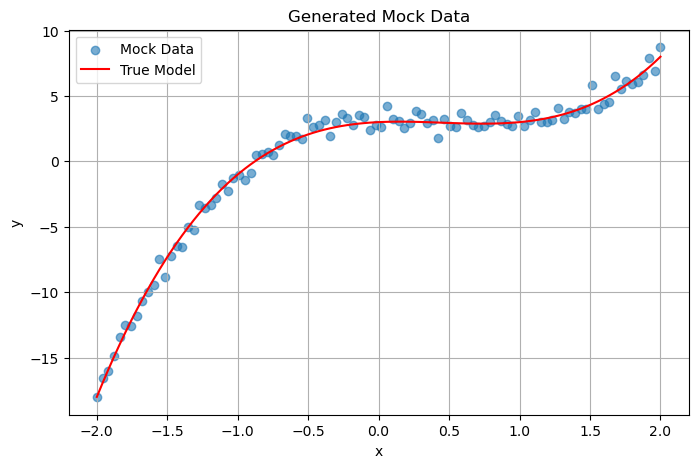

In [4]:
# Plot the generated data
plt.figure(figsize=(8, 5))
plt.scatter(x_data.numpy(), y_data.numpy(), label='Mock Data', alpha=0.6)
plt.plot(x_data.numpy(), y_true.numpy(), label='True Model', color='red')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Generated Mock Data')
plt.legend()
plt.grid(True)
plt.show()


In [5]:
# 2. Define the Pyro model for inference
def pyro_model(x_obs, y_obs=None):
    """Pyro model to infer the parameters of the cubic polynomial."""
    # Define priors for the parameters
    # Using relatively wide priors as we don't have strong prior beliefs
    a = pyro.sample("a", dist.Normal(0., 5.))
    b = pyro.sample("b", dist.Normal(0., 5.))
    c = pyro.sample("c", dist.Normal(0., 5.))
    d = pyro.sample("d", dist.Normal(0., 5.))
    
    # Define the model likelihood
    sigma = pyro.sample("sigma", dist.HalfCauchy(1.)) # Prior for noise standard deviation

    # Calculate the predicted y values based on the sampled parameters
    y_pred = a * x_obs**3 + b * x_obs**2 + c * x_obs + d

    # Sample the observed data using a Normal likelihood
    with pyro.plate("data", len(x_obs)):
        pyro.sample("obs", dist.Normal(y_pred, sigma), obs=y_obs)

In [6]:
# 3. Run MCMC inference
# Set up the NUTS kernel
kernel = NUTS(pyro_model)

# Run MCMC
num_mcmc_samples = 1000
warmup_steps = 500
mcmc = MCMC(kernel, num_samples=num_mcmc_samples, warmup_steps=warmup_steps, num_chains=1)
mcmc.run(x_data, y_data)

Sample: 100%|██████████| 1500/1500 [00:11, 126.16it/s, step size=2.68e-01, acc. prob=0.935]



                mean       std    median      2.5%     97.5%     n_eff     r_hat
         a      1.50      0.04      1.50      1.41      1.59    451.39      1.00
         b     -2.05      0.05     -2.05     -2.13     -1.96    687.40      1.00
         c      0.55      0.12      0.55      0.29      0.75    457.19      1.00
         d      3.12      0.08      3.12      2.96      3.27    606.44      1.00
     sigma      0.53      0.04      0.53      0.47      0.61    655.71      1.00

Number of divergences: 0


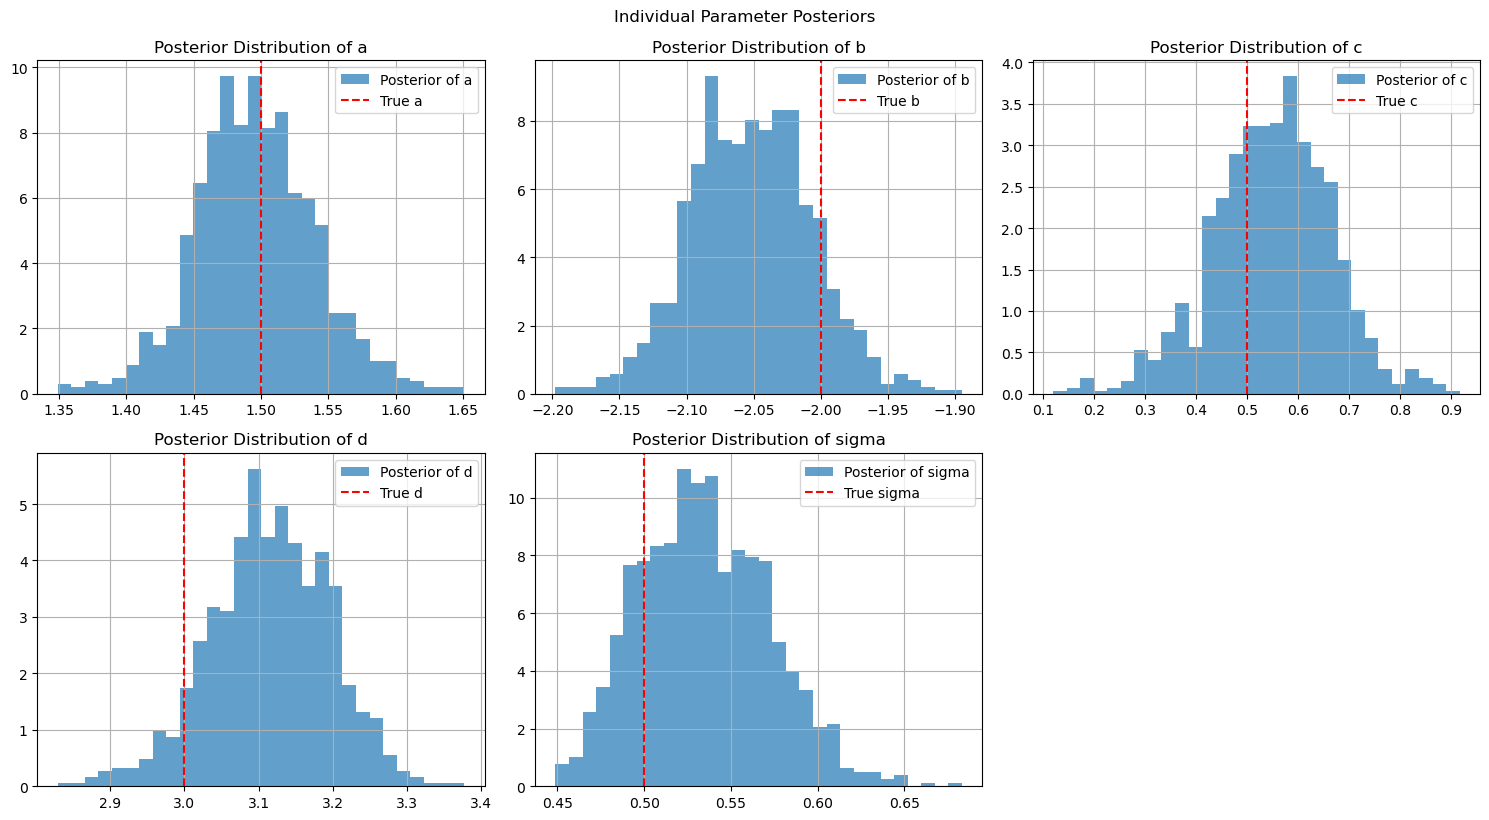

In [7]:
# 4. Analyze the results
# Get posterior samples
posterior_samples = mcmc.get_samples()

# Print summary statistics
mcmc.summary(prob=0.95)

# Plot posterior distributions
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
param_names_all = ["a", "b", "c", "d", "sigma"]
true_values_all = [true_a, true_b, true_c, true_d, noise_std]

for i, param in enumerate(param_names_all):
    samples = posterior_samples[param].numpy()
    axes[i].hist(samples, bins=30, density=True, alpha=0.7, label=f'Posterior of {param}')
    axes[i].axvline(true_values_all[i], color='red', linestyle='--', label=f'True {param}')
    axes[i].set_title(f'Posterior Distribution of {param}')
    axes[i].legend()
    axes[i].grid(True)

# Remove the empty subplot if any
if len(param_names_all) < len(axes):
    fig.delaxes(axes[-1])

plt.tight_layout()
plt.suptitle("Individual Parameter Posteriors", y=1.02) # Add a title to avoid overlap
plt.show()


Removed no burn in


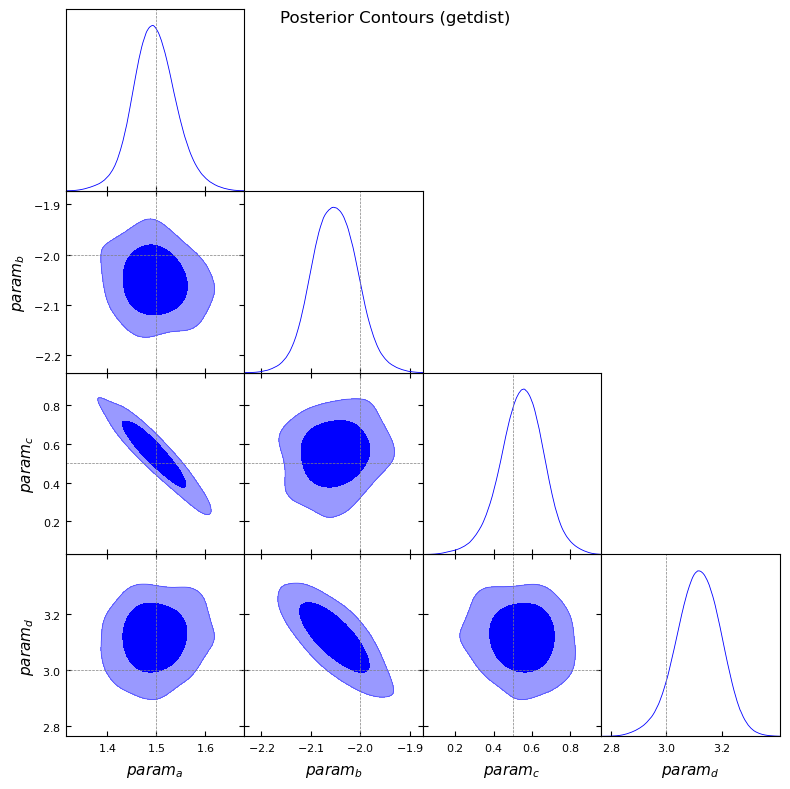

In [8]:
# 5. Create Triangle Plot with getdist
# Select only the parameters of interest for the triangle plot (a, b, c, d)
param_names_triangle = ['a', 'b', 'c', 'd']
true_values_triangle = [true_a, true_b, true_c, true_d]

# Convert posterior samples to numpy array for getdist
samples_numpy = np.vstack([posterior_samples[p].numpy() for p in param_names_triangle]).T

# Create an MCSamples object
names = param_names_triangle
labels = [f"param_{p}" for p in param_names_triangle] # Or use more descriptive labels
mcs = MCSamples(samples=samples_numpy, names=names, labels=labels)

# Generate the triangle plot
g = plots.get_subplot_plotter()
g.triangle_plot(mcs,
                filled=True,
                markers={p: v for p, v in zip(param_names_triangle, true_values_triangle)},
                legend_labels=[], # No legend needed for single dataset
                contour_colors=['blue'])

plt.suptitle("Posterior Contours (getdist)")
plt.show()

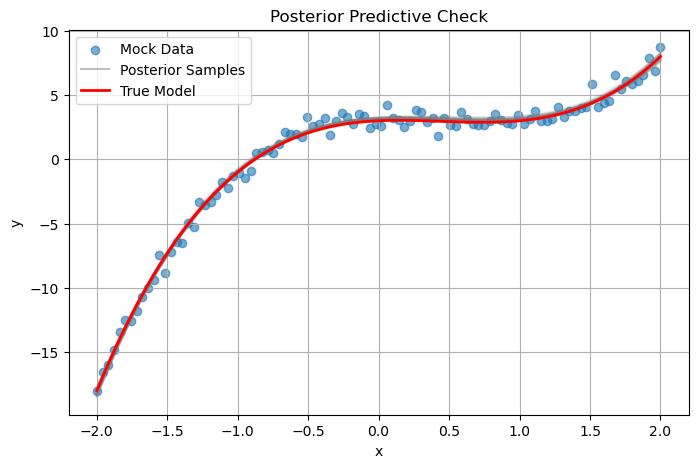

In [9]:
# Optional: Plot some posterior predictive samples
plt.figure(figsize=(8, 5))
plt.scatter(x_data.numpy(), y_data.numpy(), label='Mock Data', alpha=0.6)
# Plot a few posterior samples
num_plot_samples = 50
indices = np.random.choice(num_mcmc_samples, num_plot_samples, replace=False)
for idx in indices:
    a_sample = posterior_samples['a'][idx]
    b_sample = posterior_samples['b'][idx]
    c_sample = posterior_samples['c'][idx]
    d_sample = posterior_samples['d'][idx]
    y_pred_sample = true_model(x_data, a_sample, b_sample, c_sample, d_sample)
    plt.plot(x_data.numpy(), y_pred_sample.numpy(), color='gray', alpha=0.1)

plt.plot([], [], color='gray', alpha=0.5, label='Posterior Samples') # Dummy plot for legend
plt.plot(x_data.numpy(), y_true.numpy(), label='True Model', color='red', linewidth=2)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Posterior Predictive Check')
plt.legend()
plt.grid(True)
plt.show()

# more complicated example


In [10]:
# 1. Define the true model and generate mock data (Vector Output)
def true_model(x, a, b, c, d):
    """A model returning a 2D vector: [cubic(x), sine(x)]."""
    cubic_part = a * x**3 + b * x**2 + c * x + d
    sine_part = a * torch.sin(b * x) # Reuse parameters a, b for simplicity
    return torch.stack([cubic_part, sine_part], dim=-1) # Shape: (num_samples, 2)

In [11]:
# True parameter values
true_a = 1.5
true_b = -2.0
true_c = 0.5
true_d = 3.0
noise_std = 0.5 # Same noise std for both dimensions for simplicity

In [12]:
# Generate mock data
num_samples = 100
x_data = torch.linspace(-2, 2, num_samples)
y_true = true_model(x_data, true_a, true_b, true_c, true_d) # Shape: (num_samples, 2)
# Add noise independently to each dimension
noise = noise_std * torch.randn_like(y_true) # Shape: (num_samples, 2)
y_data = y_true + noise # Shape: (num_samples, 2)

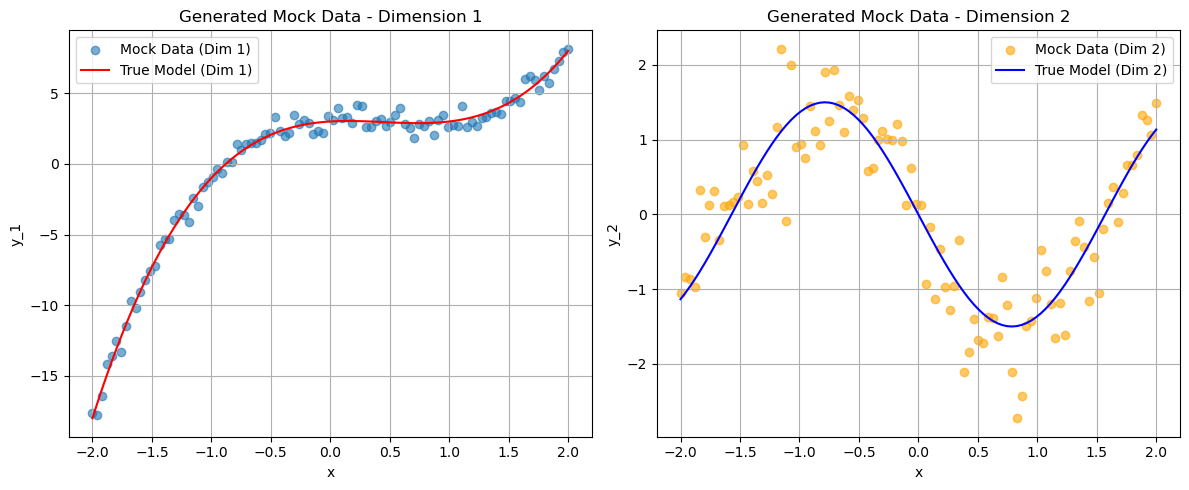

In [13]:

# Plot the generated data (plot each dimension)
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(x_data.numpy(), y_data[:, 0].numpy(), label='Mock Data (Dim 1)', alpha=0.6)
plt.plot(x_data.numpy(), y_true[:, 0].numpy(), label='True Model (Dim 1)', color='red')
plt.xlabel('x')
plt.ylabel('y_1')
plt.title('Generated Mock Data - Dimension 1')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.scatter(x_data.numpy(), y_data[:, 1].numpy(), label='Mock Data (Dim 2)', alpha=0.6, color='orange')
plt.plot(x_data.numpy(), y_true[:, 1].numpy(), label='True Model (Dim 2)', color='blue')
plt.xlabel('x')
plt.ylabel('y_2')
plt.title('Generated Mock Data - Dimension 2')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


In [14]:
# 2. Define the Pyro model for inference (Vector Likelihood)
def pyro_model(x_obs, y_obs=None):
    """Pyro model to infer parameters with vector output."""
    # Define priors for the parameters
    a = pyro.sample("a", dist.Normal(0., 5.))
    b = pyro.sample("b", dist.Normal(0., 5.))
    c = pyro.sample("c", dist.Normal(0., 5.))
    d = pyro.sample("d", dist.Normal(0., 5.))
    
    # Define the model likelihood noise
    sigma = pyro.sample("sigma", dist.HalfCauchy(1.)) # Single noise std for both dims

    # Calculate the predicted y vectors based on the sampled parameters
    # Need to replicate the logic from true_model
    cubic_part_pred = a * x_obs**3 + b * x_obs**2 + c * x_obs + d
    sine_part_pred = a * torch.sin(b * x_obs)
    y_pred = torch.stack([cubic_part_pred, sine_part_pred], dim=-1) # Shape: (num_samples, 2)

    # Sample the observed data using a Normal likelihood for vectors
    # Use .to_event(1) to treat the last dimension (size 2) as the event shape
    # This assumes independence between the dimensions given the parameters
    with pyro.plate("data", len(x_obs)):
        pyro.sample("obs", dist.Normal(y_pred, sigma).to_event(1), obs=y_obs)


In [15]:
# 3. Run MCMC inference
# Set up the NUTS kernel
kernel = NUTS(pyro_model)

# Run MCMC
num_mcmc_samples = 1000
warmup_steps = 500
mcmc = MCMC(kernel, num_samples=num_mcmc_samples, warmup_steps=warmup_steps, num_chains=1)
mcmc.run(x_data, y_data)

Sample: 100%|██████████| 1500/1500 [00:11, 132.36it/s, step size=3.28e-01, acc. prob=0.925]



                mean       std    median      2.5%     97.5%     n_eff     r_hat
         a      1.54      0.04      1.53      1.47      1.61    479.87      1.00
         b     -1.99      0.03     -1.98     -2.03     -1.93    833.41      1.00
         c      0.40      0.10      0.41      0.20      0.58    439.46      1.00
         d      2.99      0.06      2.99      2.88      3.12    642.60      1.00
     sigma      0.50      0.03      0.50      0.45      0.55    572.48      1.00

Number of divergences: 0


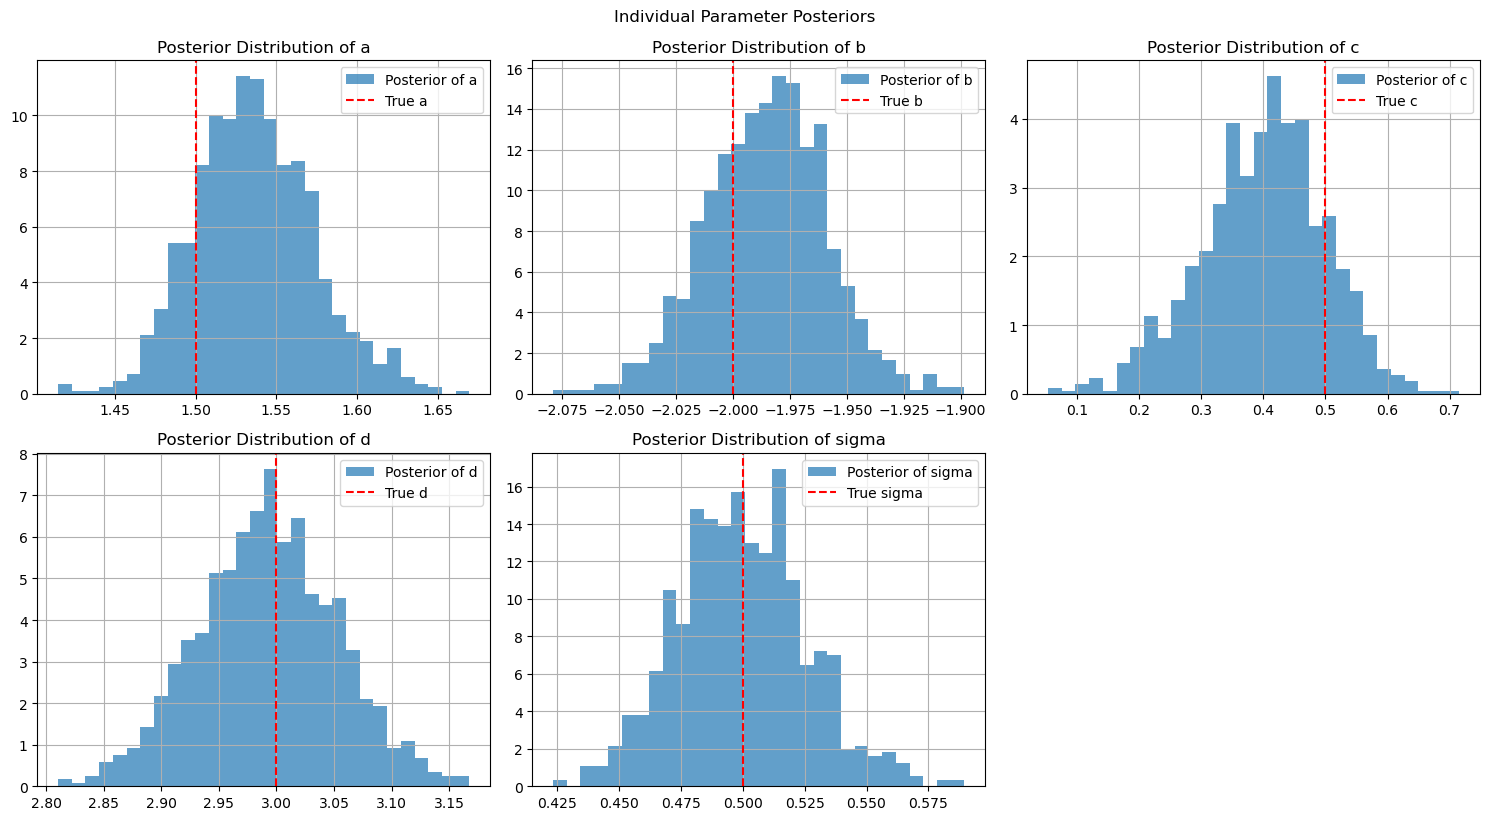

Removed no burn in


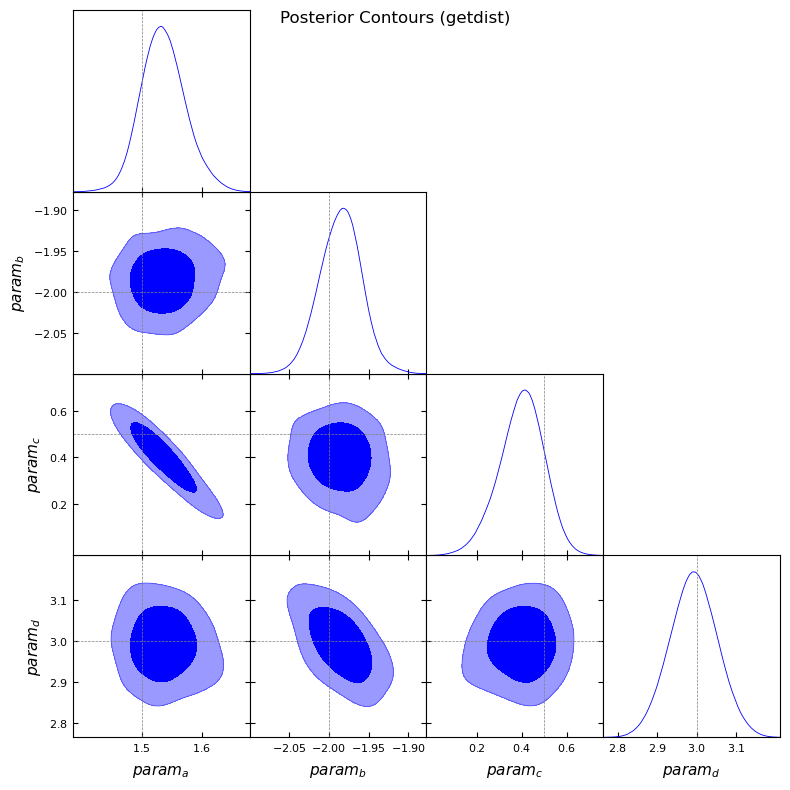

In [16]:

# 4. Analyze the results
# Get posterior samples
posterior_samples = mcmc.get_samples()

# Print summary statistics
mcmc.summary(prob=0.95)

# Plot posterior distributions
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
param_names_all = ["a", "b", "c", "d", "sigma"]
true_values_all = [true_a, true_b, true_c, true_d, noise_std]

for i, param in enumerate(param_names_all):
    samples = posterior_samples[param].numpy()
    axes[i].hist(samples, bins=30, density=True, alpha=0.7, label=f'Posterior of {param}')
    axes[i].axvline(true_values_all[i], color='red', linestyle='--', label=f'True {param}')
    axes[i].set_title(f'Posterior Distribution of {param}')
    axes[i].legend()
    axes[i].grid(True)

# Remove the empty subplot if any
if len(param_names_all) < len(axes):
    fig.delaxes(axes[-1])

plt.tight_layout()
plt.suptitle("Individual Parameter Posteriors", y=1.02) # Add a title to avoid overlap
plt.show()

# 5. Create Triangle Plot with getdist
# Select only the parameters of interest for the triangle plot (a, b, c, d)
param_names_triangle = ['a', 'b', 'c', 'd']
true_values_triangle = [true_a, true_b, true_c, true_d]

# Convert posterior samples to numpy array for getdist
samples_numpy = np.vstack([posterior_samples[p].numpy() for p in param_names_triangle]).T

# Create an MCSamples object
names = param_names_triangle
labels = [f"param_{p}" for p in param_names_triangle] # Or use more descriptive labels
mcs = MCSamples(samples=samples_numpy, names=names, labels=labels)

# Generate the triangle plot
g = plots.get_subplot_plotter()
g.triangle_plot(mcs,
                filled=True,
                markers={p: v for p, v in zip(param_names_triangle, true_values_triangle)},
                legend_labels=[], # No legend needed for single dataset
                contour_colors=['blue'])

plt.suptitle("Posterior Contours (getdist)")
plt.show()


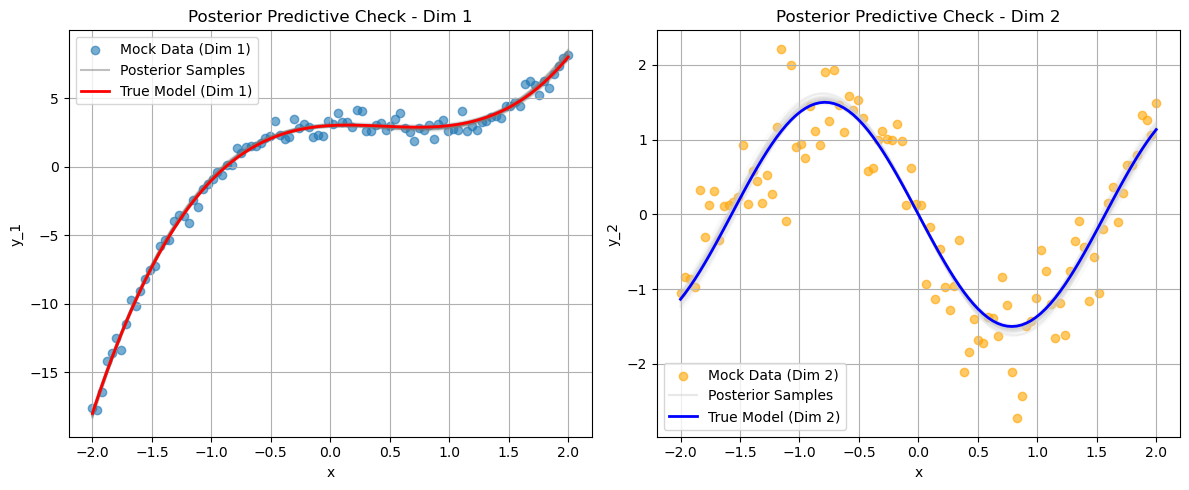

In [17]:

# Optional: Plot some posterior predictive samples (Vector Output)
plt.figure(figsize=(12, 5))

# Plot Dimension 1
plt.subplot(1, 2, 1)
plt.scatter(x_data.numpy(), y_data[:, 0].numpy(), label='Mock Data (Dim 1)', alpha=0.6)
num_plot_samples = 50
indices = np.random.choice(num_mcmc_samples, num_plot_samples, replace=False)
for idx in indices:
    a_sample = posterior_samples['a'][idx]
    b_sample = posterior_samples['b'][idx]
    c_sample = posterior_samples['c'][idx]
    d_sample = posterior_samples['d'][idx]
    # Get the 2D prediction
    y_pred_sample_vec = true_model(x_data, a_sample, b_sample, c_sample, d_sample)
    plt.plot(x_data.numpy(), y_pred_sample_vec[:, 0].numpy(), color='gray', alpha=0.1)

plt.plot([], [], color='gray', alpha=0.5, label='Posterior Samples') # Dummy plot for legend
plt.plot(x_data.numpy(), y_true[:, 0].numpy(), label='True Model (Dim 1)', color='red', linewidth=2)
plt.xlabel('x')
plt.ylabel('y_1')
plt.title('Posterior Predictive Check - Dim 1')
plt.legend()
plt.grid(True)

# Plot Dimension 2
plt.subplot(1, 2, 2)
plt.scatter(x_data.numpy(), y_data[:, 1].numpy(), label='Mock Data (Dim 2)', alpha=0.6, color='orange')
for idx in indices: # Use the same sample indices
    a_sample = posterior_samples['a'][idx]
    b_sample = posterior_samples['b'][idx]
    c_sample = posterior_samples['c'][idx]
    d_sample = posterior_samples['d'][idx]
    # Get the 2D prediction
    y_pred_sample_vec = true_model(x_data, a_sample, b_sample, c_sample, d_sample)
    plt.plot(x_data.numpy(), y_pred_sample_vec[:, 1].numpy(), color='lightgray', alpha=0.1)

plt.plot([], [], color='lightgray', alpha=0.5, label='Posterior Samples') # Dummy plot for legend
plt.plot(x_data.numpy(), y_true[:, 1].numpy(), label='True Model (Dim 2)', color='blue', linewidth=2)
plt.xlabel('x')
plt.ylabel('y_2')
plt.title('Posterior Predictive Check - Dim 2')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()



# Long datavector example

In [56]:
# 1. Define the true model and generate mock data (Long Vector Output)
DATA_VECTOR_SIZE = 50

def true_model(a, b, c, d):
    """A model returning a long vector based on parameters."""
    # Example: Create a vector where elements depend on parameters
    indices = torch.arange(DATA_VECTOR_SIZE, dtype=torch.float32)
    # Ensure calculations are stable and produce varied outputs
    term1 = a * torch.sin(indices / (5 * (abs(b) + 1)))
    term2 = c * torch.cos(indices / (5 * (abs(d) + 1)))
    # Combine terms and add some baseline variation
    vector = term1 + term2 + b + indices * d * 0.01
    return vector # Shape: (DATA_VECTOR_SIZE,)

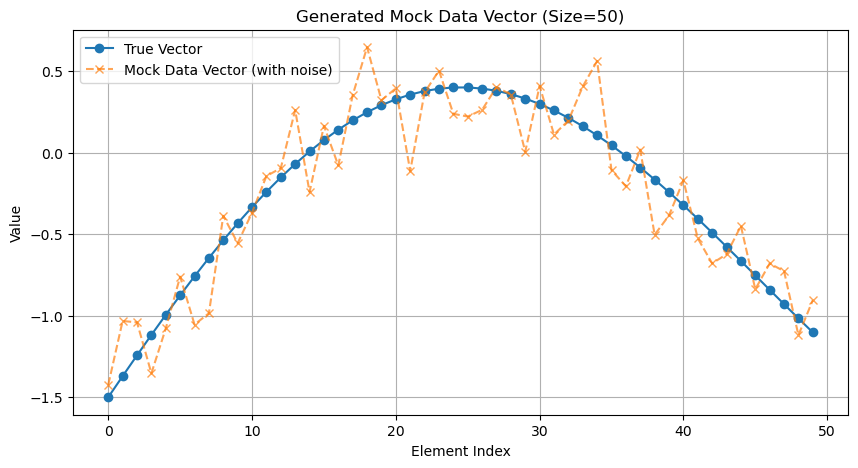

In [57]:
# True parameter values
true_a = 1.5
true_b = -2.0
true_c = 0.5
true_d = 3.0
# Known noise standard deviation for each independent element
noise_std = 0.2

# Generate ONE mock data vector
y_true = true_model(true_a, true_b, true_c, true_d) # Shape: (DATA_VECTOR_SIZE,)
# Add independent Gaussian noise
noise = noise_std * torch.randn(DATA_VECTOR_SIZE)
y_data = y_true + noise # Shape: (DATA_VECTOR_SIZE,)

# Plot the generated data vector
plt.figure(figsize=(10, 5))
plt.plot(y_true.numpy(), label='True Vector', marker='o', linestyle='-')
plt.plot(y_data.numpy(), label='Mock Data Vector (with noise)', marker='x', linestyle='--', alpha=0.7)
plt.xlabel('Element Index')
plt.ylabel('Value')
plt.title(f'Generated Mock Data Vector (Size={DATA_VECTOR_SIZE})')
plt.legend()
plt.grid(True)
plt.show()


In [58]:


# 2. Define the Pyro model for inference (Long Vector Likelihood)
def pyro_model(y_obs=None):
    """Pyro model to infer parameters with long vector output."""
    # Define priors for the parameters
    a = pyro.sample("a", dist.Normal(0., 5.))
    b = pyro.sample("b", dist.Normal(0., 5.))
    c = pyro.sample("c", dist.Normal(0., 5.))
    d = pyro.sample("d", dist.Normal(0., 5.))
    
    # Calculate the predicted vector based on the sampled parameters
    y_pred = true_model(a, b, c, d) # Use the same generation logic

    # Known, fixed noise standard deviation (as per prompt)
    sigma = noise_std

    # Sample the observed data vector using a Normal likelihood for each element
    # Use .to_event(1) to treat the vector elements as independent dimensions of a single event
    pyro.sample("obs", dist.Normal(y_pred, sigma).to_event(1), obs=y_obs)


In [59]:

# 3. Run MCMC inference
# Set up the NUTS kernel
kernel = NUTS(pyro_model)

# Run MCMC
num_mcmc_samples = 10000
warmup_steps = 5000
mcmc = MCMC(kernel, num_samples=num_mcmc_samples, warmup_steps=warmup_steps, num_chains=1)
# Pass only the observed data vector
mcmc.run(y_data)


Sample: 100%|██████████| 15000/15000 [08:48, 28.40it/s, step size=1.59e-01, acc. prob=0.961]



                mean       std    median      2.5%     97.5%     n_eff     r_hat
         a      2.10      1.05      1.71      1.05      4.99    179.08      1.00
         b     -3.07      1.73     -2.54     -6.64     -0.37    223.40      1.00
         c      1.59      1.71      1.09     -0.94      5.12    240.37      1.00
         d      3.31      0.82      3.20      2.41      6.14     59.11      1.01

Number of divergences: 0


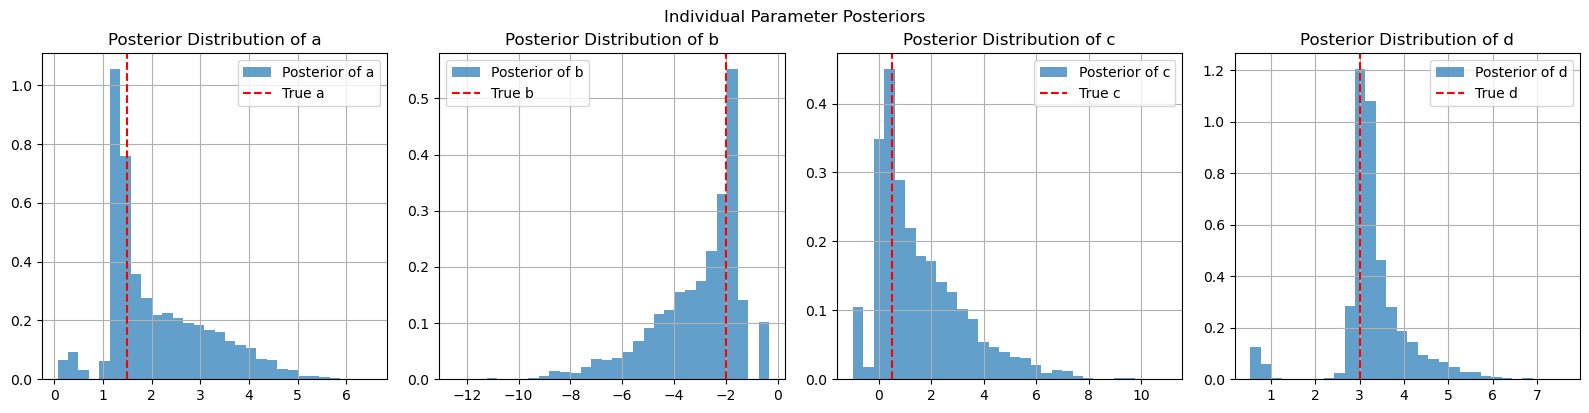

In [60]:

# 4. Analyze the results
# Get posterior samples
posterior_samples = mcmc.get_samples()

# Print summary statistics (excluding sigma as it's fixed)
mcmc.summary(prob=0.95)

# Plot posterior distributions (only for inferred parameters a, b, c, d)
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
axes = axes.flatten()
param_names_inf = ["a", "b", "c", "d"]
true_values_inf = [true_a, true_b, true_c, true_d]

for i, param in enumerate(param_names_inf):
    samples = posterior_samples[param].numpy()
    axes[i].hist(samples, bins=30, density=True, alpha=0.7, label=f'Posterior of {param}')
    axes[i].axvline(true_values_inf[i], color='red', linestyle='--', label=f'True {param}')
    axes[i].set_title(f'Posterior Distribution of {param}')
    axes[i].legend()
    axes[i].grid(True)

plt.tight_layout()
plt.suptitle("Individual Parameter Posteriors", y=1.02)
plt.show()


Removed no burn in


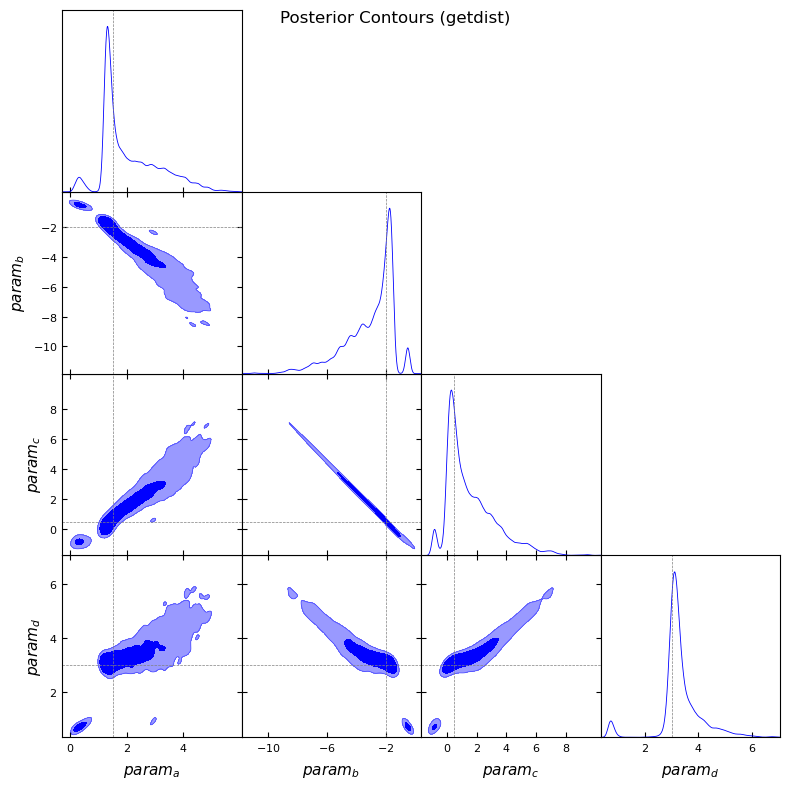

In [61]:

# 5. Create Triangle Plot with getdist
# Parameters a, b, c, d
param_names_triangle = ['a', 'b', 'c', 'd']
true_values_triangle = [true_a, true_b, true_c, true_d]

# Convert posterior samples to numpy array for getdist
samples_numpy = np.vstack([posterior_samples[p].numpy() for p in param_names_triangle]).T

# Create an MCSamples object
names = param_names_triangle
labels = [f"param_{p}" for p in param_names_triangle]
mcs = MCSamples(samples=samples_numpy, names=names, labels=labels)

# Generate the triangle plot
g = plots.get_subplot_plotter()
g.triangle_plot(mcs,
                filled=True,
                markers={p: v for p, v in zip(param_names_triangle, true_values_triangle)},
                legend_labels=[],
                contour_colors=['blue'])

plt.suptitle("Posterior Contours (getdist)")
plt.show()


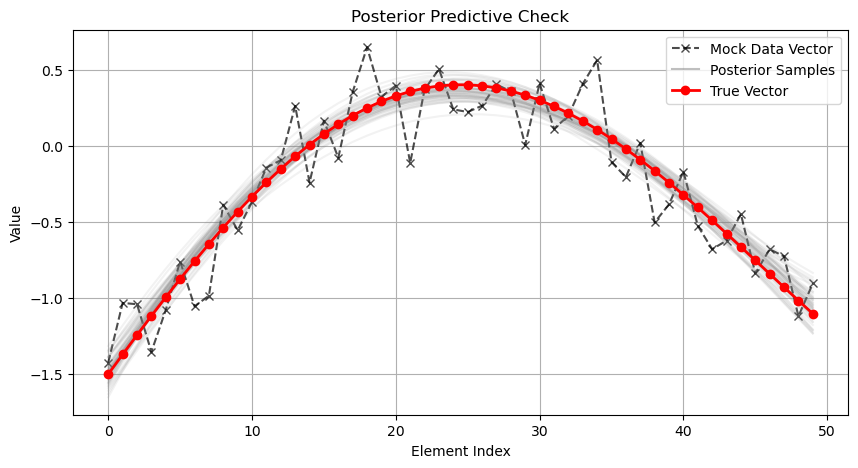

In [62]:

# Optional: Plot some posterior predictive samples (Compare data vectors)
plt.figure(figsize=(10, 5))
plt.plot(y_data.numpy(), label='Mock Data Vector', marker='x', linestyle='--', alpha=0.7, color='black')

# Plot a few posterior predictive samples
num_plot_samples = 50
indices = np.random.choice(num_mcmc_samples, num_plot_samples, replace=False)
for idx in indices:
    a_sample = posterior_samples['a'][idx]
    b_sample = posterior_samples['b'][idx]
    c_sample = posterior_samples['c'][idx]
    d_sample = posterior_samples['d'][idx]
    y_pred_sample = true_model(a_sample, b_sample, c_sample, d_sample)
    plt.plot(y_pred_sample.numpy(), color='gray', alpha=0.1)

plt.plot([], [], color='gray', alpha=0.5, label='Posterior Samples') # Dummy plot for legend
plt.plot(y_true.numpy(), label='True Vector', marker='o', linestyle='-', color='red', linewidth=2)
plt.xlabel('Element Index')
plt.ylabel('Value')
plt.title('Posterior Predictive Check')
plt.legend()
plt.grid(True)
plt.show()



# Covariance

In [63]:
# 1. Define the true model and generate mock data (Long Vector Output)
DATA_VECTOR_SIZE = 50

def true_model(a, b, c, d):
    """A model returning a long vector based on parameters."""
    # Example: Create a vector where elements depend on parameters
    indices = torch.arange(DATA_VECTOR_SIZE, dtype=torch.float32)
    # Ensure calculations are stable and produce varied outputs
    term1 = a * torch.sin(indices / (5 * (abs(b) + 1)))
    term2 = c * torch.cos(indices / (5 * (abs(d) + 1)))
    # Combine terms and add some baseline variation
    vector = term1 + term2 + b + indices * d * 0.01
    return vector # Shape: (DATA_VECTOR_SIZE,)

# True parameter values
true_a = 1.5
true_b = -2.0
true_c = 0.5
true_d = 3.0
# Known noise standard deviation for each independent element
noise_std = 0.2

# Generate ONE mock data vector
y_true = true_model(true_a, true_b, true_c, true_d) # Shape: (DATA_VECTOR_SIZE,)


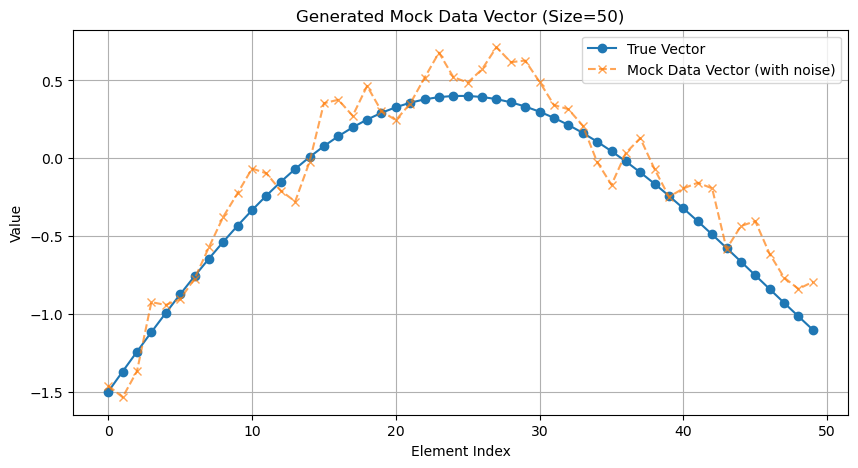

In [78]:

# --- Define the Known Covariance Matrix --- 
# Option 1: Independent noise (diagonal covariance)
# covariance_matrix = torch.eye(DATA_VECTOR_SIZE) * (noise_std**2)

# Option 2: Example of a non-diagonal covariance (e.g., exponential decay)
indices = torch.arange(DATA_VECTOR_SIZE, dtype=torch.float32)
distance_matrix = torch.abs(indices[:, None] - indices[None, :])
correlation_length = 5.0 # Example correlation length
covariance_matrix = (noise_std**2) * torch.exp(-distance_matrix / correlation_length)
# Ensure positive definiteness (add small jitter to diagonal)
covariance_matrix += torch.eye(DATA_VECTOR_SIZE) * 1e-6 

# Generate noise using the covariance matrix
# We need a distribution that can sample from this covariance
mvn_noise_dist = dist.MultivariateNormal(torch.zeros(DATA_VECTOR_SIZE), covariance_matrix)
noise = mvn_noise_dist.sample()
y_data = y_true + noise # Shape: (DATA_VECTOR_SIZE,)

# Plot the generated data vector
plt.figure(figsize=(10, 5))
plt.plot(y_true.numpy(), label='True Vector', marker='o', linestyle='-')
plt.plot(y_data.numpy(), label='Mock Data Vector (with noise)', marker='x', linestyle='--', alpha=0.7)
plt.xlabel('Element Index')
plt.ylabel('Value')
plt.title(f'Generated Mock Data Vector (Size={DATA_VECTOR_SIZE})')
plt.legend()
plt.grid(True)
plt.show()


In [79]:
# 2. Define the Pyro model for inference (Multivariate Normal Likelihood)
def pyro_model(y_obs=None):
    """Pyro model using MultivariateNormal likelihood."""
    # Define priors for the parameters
    a = pyro.sample("a", dist.Normal(0., 5.))
    b = pyro.sample("b", dist.Normal(0., 5.))
    c = pyro.sample("c", dist.Normal(0., 5.))
    d = pyro.sample("d", dist.Normal(0., 5.))
    
    # Calculate the predicted vector based on the sampled parameters
    y_pred = true_model(a, b, c, d) # Use the same generation logic

    # Use the known, fixed covariance matrix for the likelihood
    # Ensure covariance_matrix is accessible here (e.g., pass as arg or define globally)
    pyro.sample("obs", dist.MultivariateNormal(y_pred, covariance_matrix=covariance_matrix), obs=y_obs)


In [80]:

# 3. Run MCMC inference
# Set up the NUTS kernel
kernel = NUTS(pyro_model)

# Run MCMC
num_mcmc_samples = 1000
warmup_steps = 1000
mcmc = MCMC(kernel, num_samples=num_mcmc_samples, warmup_steps=warmup_steps, num_chains=1)
# Pass only the observed data vector
mcmc.run(y_data)


Sample: 100%|██████████| 2000/2000 [00:59, 33.58it/s, step size=3.13e-02, acc. prob=0.942]



                mean       std    median      2.5%     97.5%     n_eff     r_hat
         a      2.72      1.30      2.47      1.01      5.28     46.86      1.00
         b     -3.79      2.03     -3.35     -7.60     -1.11     38.41      1.02
         c      2.27      2.05      1.79     -0.54      6.32     39.40      1.02
         d      3.66      0.98      3.54      1.48      5.58     84.02      1.02

Number of divergences: 0


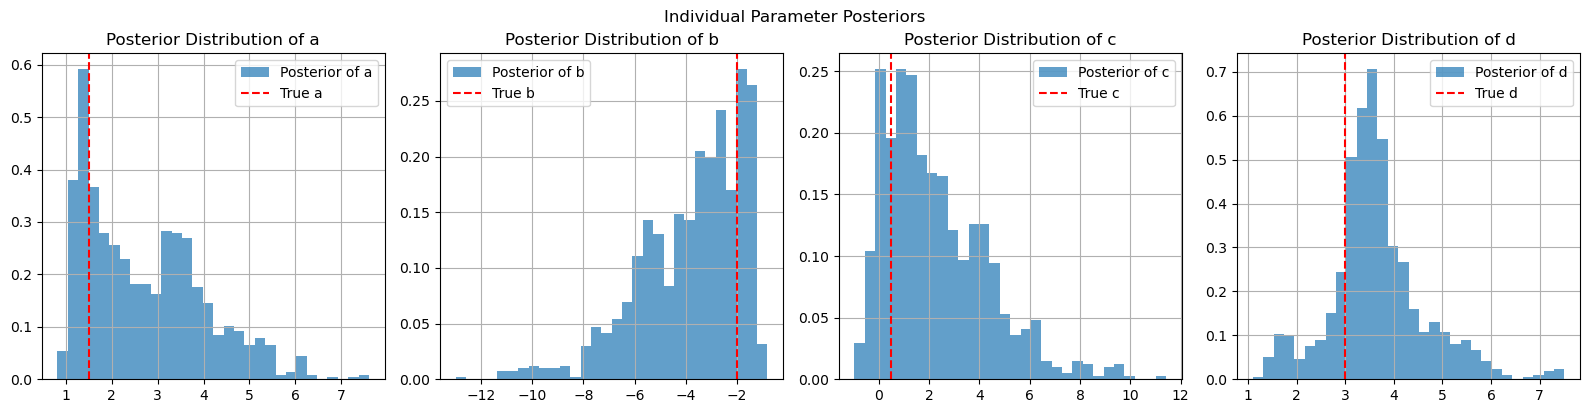

In [81]:

# 4. Analyze the results
# Get posterior samples
posterior_samples = mcmc.get_samples()

# Print summary statistics (excluding sigma as it's fixed)
mcmc.summary(prob=0.95)

# Plot posterior distributions (only for inferred parameters a, b, c, d)
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
axes = axes.flatten()
param_names_inf = ["a", "b", "c", "d"]
true_values_inf = [true_a, true_b, true_c, true_d]

for i, param in enumerate(param_names_inf):
    samples = posterior_samples[param].numpy()
    axes[i].hist(samples, bins=30, density=True, alpha=0.7, label=f'Posterior of {param}')
    axes[i].axvline(true_values_inf[i], color='red', linestyle='--', label=f'True {param}')
    axes[i].set_title(f'Posterior Distribution of {param}')
    axes[i].legend()
    axes[i].grid(True)

plt.tight_layout()
plt.suptitle("Individual Parameter Posteriors", y=1.02)
plt.show()


In [82]:

# 5. Create Triangle Plot with getdist
# Parameters a, b, c, d
param_names_triangle = ['a', 'b', 'c', 'd']
true_values_triangle = [true_a, true_b, true_c, true_d]

# Convert posterior samples to numpy array for getdist
samples_numpy = np.vstack([posterior_samples[p].numpy() for p in param_names_triangle]).T

# Create an MCSamples object
names = param_names_triangle
labels = [f"param_{p}" for p in param_names_triangle]
mcs = MCSamples(samples=samples_numpy, names=names, labels=labels)


Removed no burn in


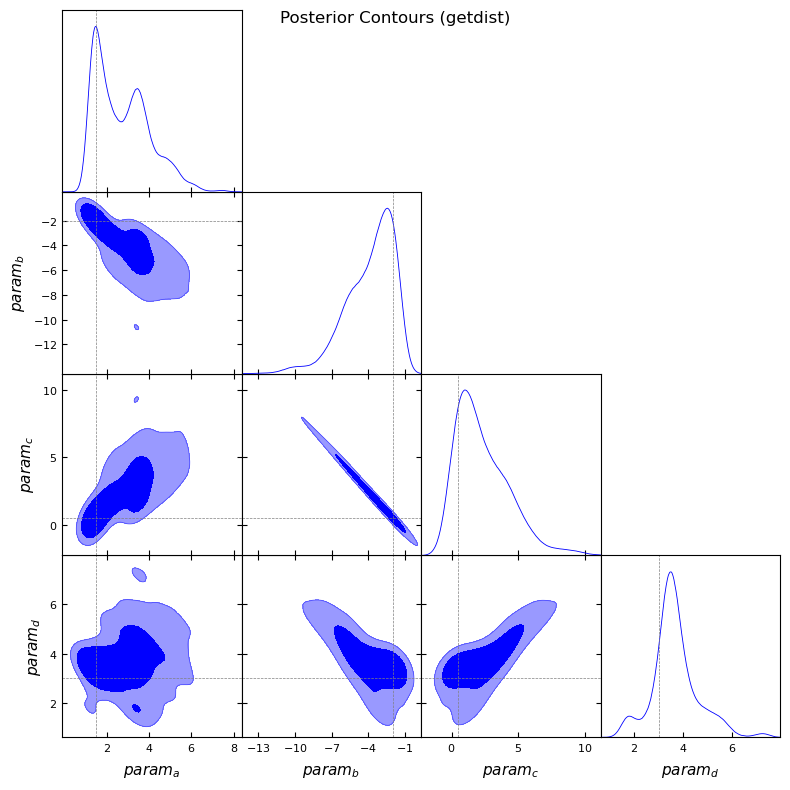

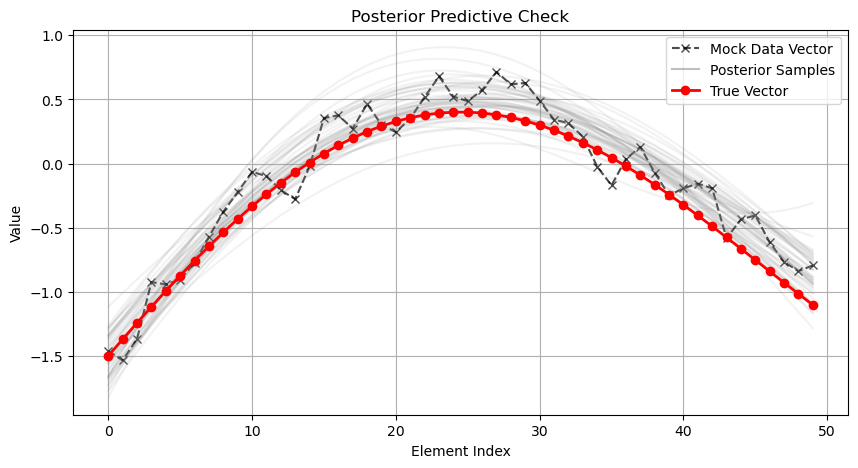

In [83]:

# Generate the triangle plot
g = plots.get_subplot_plotter()
g.triangle_plot(mcs,
                filled=True,
                markers={p: v for p, v in zip(param_names_triangle, true_values_triangle)},
                legend_labels=[],
                contour_colors=['blue'])

plt.suptitle("Posterior Contours (getdist)")
plt.show()

# Optional: Plot some posterior predictive samples (Compare data vectors)
plt.figure(figsize=(10, 5))
plt.plot(y_data.numpy(), label='Mock Data Vector', marker='x', linestyle='--', alpha=0.7, color='black')

# Plot a few posterior predictive samples
num_plot_samples = 50
indices = np.random.choice(num_mcmc_samples, num_plot_samples, replace=False)
for idx in indices:
    a_sample = posterior_samples['a'][idx]
    b_sample = posterior_samples['b'][idx]
    c_sample = posterior_samples['c'][idx]
    d_sample = posterior_samples['d'][idx]
    y_pred_sample = true_model(a_sample, b_sample, c_sample, d_sample)
    plt.plot(y_pred_sample.numpy(), color='gray', alpha=0.1)

plt.plot([], [], color='gray', alpha=0.5, label='Posterior Samples') # Dummy plot for legend
plt.plot(y_true.numpy(), label='True Vector', marker='o', linestyle='-', color='red', linewidth=2)
plt.xlabel('Element Index')
plt.ylabel('Value')
plt.title('Posterior Predictive Check')
plt.legend()
plt.grid(True)
plt.show()



# Version with Emulator

# GPR

In [29]:
import torch
import numpy as np
import pyro
import pyro.distributions as dist
from pyro.infer import MCMC, NUTS
import matplotlib.pyplot as plt
import getdist
from getdist import plots, MCSamples
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


In [30]:

# 0. Define Constants and True Model
DATA_VECTOR_SIZE = 50
NUM_TRAINING_SAMPLES = 25 # Number of parameter sets for training the regressor
NOISE_STD = 0.2 # Known noise standard deviation

def true_model(a, b, c, d):
    """The original 'true' physics model returning a long vector."""
    # Ensure input parameters are tensors for PyTorch operations
    a = torch.as_tensor(a, dtype=torch.float32)
    b = torch.as_tensor(b, dtype=torch.float32)
    c = torch.as_tensor(c, dtype=torch.float32)
    d = torch.as_tensor(d, dtype=torch.float32)

    indices = torch.arange(DATA_VECTOR_SIZE, dtype=torch.float32)
    term1 = a * torch.sin(indices / (5 * (torch.abs(b) + 1)))
    term2 = c * torch.cos(indices / (5 * (torch.abs(d) + 1)))
    vector = term1 + term2 + b + indices * d * 0.01
    return vector # Shape: (DATA_VECTOR_SIZE,)

# --- Define the Known Covariance Matrix ---
# (Using the non-diagonal example, assumed constant)
indices = torch.arange(DATA_VECTOR_SIZE, dtype=torch.float32)
distance_matrix = torch.abs(indices[:, None] - indices[None, :])
correlation_length = 5.0
covariance_matrix = (NOISE_STD**2) * torch.exp(-distance_matrix / correlation_length)
covariance_matrix += torch.eye(DATA_VECTOR_SIZE) * 1e-6 # Add jitter for stability
mvn_noise_dist = dist.MultivariateNormal(torch.zeros(DATA_VECTOR_SIZE), covariance_matrix)


In [31]:

# 1. Generate Training Data for the Regressor
def generate_training_data(num_samples):
    """Generates parameter sets and corresponding noisy data vectors."""
    param_ranges = {
        'a': (-3, 3),
        'b': (-5, 5),
        'c': (-2, 2),
        'd': (0.1, 6) # Avoid d close to zero for stability in true_model
    }
    X_train = []
    Y_train_true = []
    Y_train_noisy = []

    for _ in range(num_samples):
        params = {p: np.random.uniform(low, high) for p, (low, high) in param_ranges.items()}
        a, b, c, d = params['a'], params['b'], params['c'], params['d']

        y_true_i = true_model(a, b, c, d)
        noise_i = mvn_noise_dist.sample()
        y_noisy_i = y_true_i + noise_i

        X_train.append([a, b, c, d])
        Y_train_true.append(y_true_i.numpy()) # Store as numpy
        Y_train_noisy.append(y_noisy_i.numpy()) # Store as numpy

    return np.array(X_train), np.array(Y_train_true), np.array(Y_train_noisy)

X_train, Y_train_true, Y_train_noisy = generate_training_data(NUM_TRAINING_SAMPLES)


Text(0.5, 1.0, 'Generated Training Data Vectors (Size=50)')

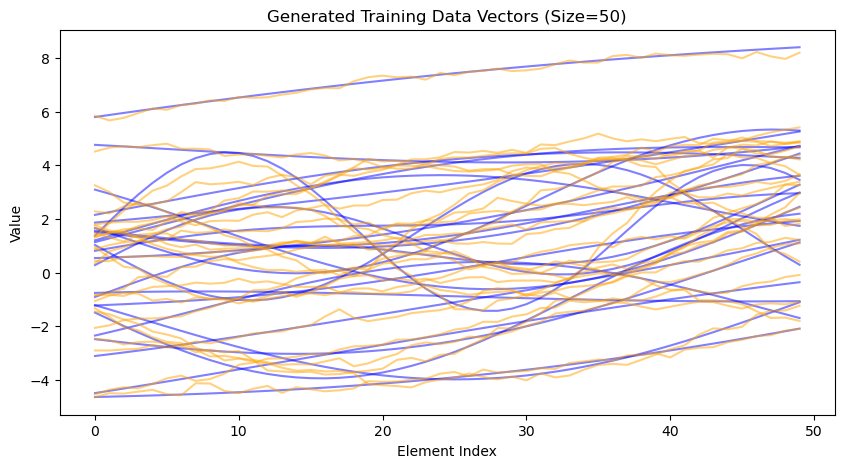

In [32]:
# plot the training data
plt.figure(figsize=(10, 5))
plt.plot(Y_train_true.T, color='blue', alpha=0.5, label='True Data Vectors')
plt.plot(Y_train_noisy.T, color='orange', alpha=0.5, label='Noisy Data Vectors')
plt.xlabel('Element Index')
plt.ylabel('Value')
plt.title(f'Generated Training Data Vectors (Size={DATA_VECTOR_SIZE})')


In [68]:

# 2. Train the Gaussian Process Regressor
# Scale the input parameters for better GPR performance
param_scaler = StandardScaler()
X_train_scaled = param_scaler.fit_transform(X_train)

# Define the GPR kernel
# Kernel choice might need tuning depending on the complexity of the true_model
kernel = C(1.0, (1e-3, 1e3)) * RBF(length_scale=np.ones(X_train.shape[1]), length_scale_bounds=(1e-2, 1e2))

# Create and train the GPR model
# We train on the NOISY data vectors, as the GPR should ideally learn the underlying smooth function
# Alternatively, train on Y_train_true if you want the GPR to represent the noise-free model
gpr = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=200, random_state=42, alpha=1e-5) # Small alpha for numerical stability
print("Training GPR...")
gpr.fit(X_train_scaled, Y_train_noisy) # Train on noisy data
print("GPR Training Complete.")
print(f"GPR Kernel after training: {gpr.kernel_}")
print(f"GPR Log-Marginal-Likelihood: {gpr.log_marginal_likelihood_value_:.3f}")


Training GPR...
GPR Training Complete.
GPR Kernel after training: 3.58**2 * RBF(length_scale=[2.49, 0.704, 4.02, 8.03])
GPR Log-Marginal-Likelihood: -2184.426


Text(0.5, 1.0, 'GPR Predictions on Training Data Vectors (Size=50)')

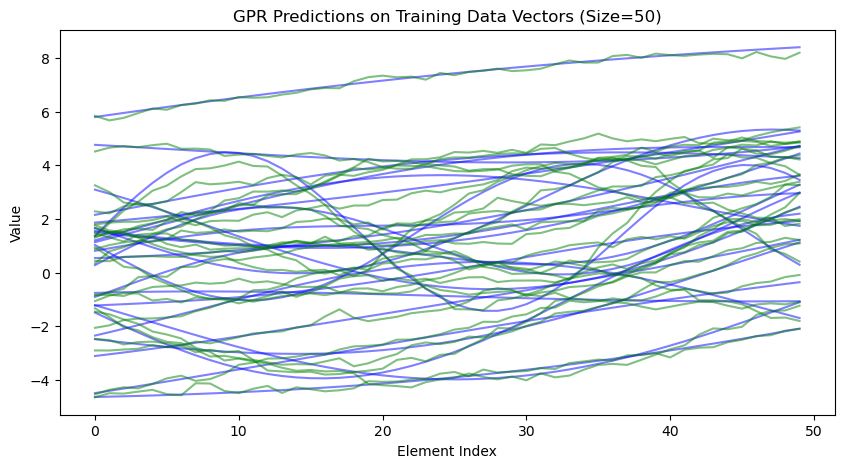

In [69]:
# show the GPR predictions for the training parameters
X_train_pred = gpr.predict(X_train_scaled, return_std=True)
Y_train_pred, Y_train_pred_std = X_train_pred
# Plot the GPR predictions
plt.figure(figsize=(10, 5))
plt.plot(Y_train_true.T, color='blue', alpha=0.5, label='True Data Vectors')
# plt.plot(Y_train_noisy.T, color='orange', alpha=0.5, label='Noisy Data Vectors')
plt.plot(Y_train_pred.T, color='green', alpha=0.5, label='GPR Predictions')
plt.xlabel('Element Index')
plt.ylabel('Value')
plt.title(f'GPR Predictions on Training Data Vectors (Size={DATA_VECTOR_SIZE})')


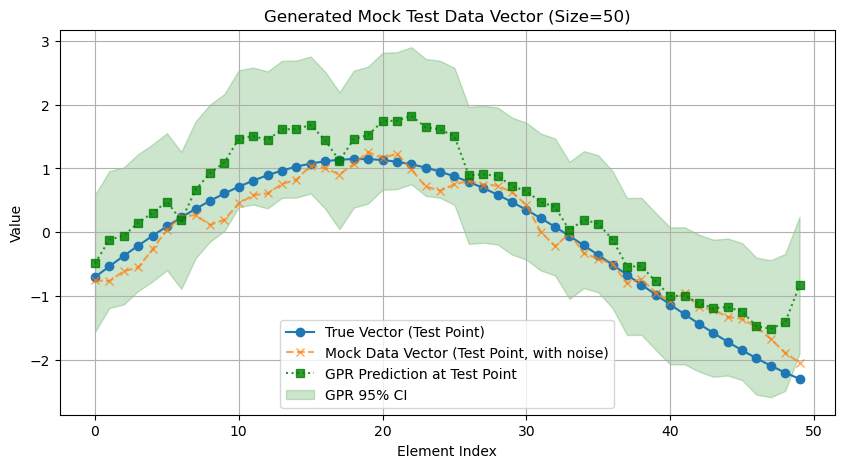

In [70]:
# 3. Generate ONE Mock Data Point for Inference (using true_model)
# Use parameters different from the training set to test generalization
test_a = 1.8
test_b = -1.5
test_c = 0.8
test_d = 2.5
test_params = np.array([[test_a, test_b, test_c, test_d]])

y_test_true = true_model(test_a, test_b, test_c, test_d)
noise_test = mvn_noise_dist.sample()
y_test_data = y_test_true + noise_test # This is the data we'll give to Pyro

# Plot the test data
plt.figure(figsize=(10, 5))
plt.plot(y_test_true.numpy(), label='True Vector (Test Point)', marker='o', linestyle='-')
plt.plot(y_test_data.numpy(), label='Mock Data Vector (Test Point, with noise)', marker='x', linestyle='--', alpha=0.7)
# Also plot the GPR prediction for this test point
test_params_scaled = param_scaler.transform(test_params)
y_gpr_pred_test, y_gpr_std_test = gpr.predict(test_params_scaled, return_std=True)
plt.plot(y_gpr_pred_test[0], label='GPR Prediction at Test Point', marker='s', linestyle=':', alpha=0.8, color='green')
plt.fill_between(np.arange(DATA_VECTOR_SIZE),
                 y_gpr_pred_test[0] - 1.96 * y_gpr_std_test[0],
                 y_gpr_pred_test[0] + 1.96 * y_gpr_std_test[0],
                 alpha=0.2, color='green', label='GPR 95% CI')
plt.xlabel('Element Index')
plt.ylabel('Value')
plt.title(f'Generated Mock Test Data Vector (Size={DATA_VECTOR_SIZE})')
plt.legend()
plt.grid(True)
plt.show()


In [71]:
# 4. Define the Pyro model using the GPR Regressor
def pyro_model_gpr(y_obs=None):
    """Pyro model using the trained GPR as the forward model."""
    # Define priors for the parameters (same as before)
    a = pyro.sample("a", dist.Normal(0., 5.))
    b = pyro.sample("b", dist.Normal(0., 5.))
    c = pyro.sample("c", dist.Normal(0., 5.))
    d = pyro.sample("d", dist.Normal(0., 5.))

    # Combine parameters into a tensor and scale them
    params_tensor = torch.stack([a, b, c, d]).unsqueeze(0) # Shape: (1, 4)
    # Convert to numpy for scaler and GPR prediction
    params_numpy = params_tensor.detach().cpu().numpy()
    params_scaled = param_scaler.transform(params_numpy) # Use the fitted scaler

    # Predict the data vector using the GPR
    # gpr.predict returns numpy array, convert back to tensor
    # Note: GPR prediction itself doesn't directly incorporate the known covariance.
    # The covariance is used in the likelihood below.
    y_pred_numpy, _ = gpr.predict(params_scaled, return_std=True) # We only need the mean prediction here
    y_pred = torch.tensor(y_pred_numpy[0], dtype=torch.float32) # Shape: (DATA_VECTOR_SIZE,)

    # Use the known, fixed covariance matrix for the likelihood
    pyro.sample("obs", dist.MultivariateNormal(y_pred, covariance_matrix=covariance_matrix), obs=y_obs)


In [ ]:

# 5. Run MCMC inference using the GPR-based model
# Set up the NUTS kernel
kernel_gpr = NUTS(pyro_model_gpr, adapt_step_size=True)

# Run MCMC
num_mcmc_samples = 1000
warmup_steps = 500
mcmc_gpr = MCMC(kernel_gpr, num_samples=num_mcmc_samples, warmup_steps=warmup_steps, num_chains=1)
print("\nRunning MCMC with GPR model...")
# Pass the TEST observed data vector
mcmc_gpr.run(y_test_data)
print("MCMC with GPR model complete.")

# 6. Analyze the results from the GPR-based inference
# Get posterior samples
posterior_samples_gpr = mcmc_gpr.get_samples()

# Print summary statistics
mcmc_gpr.summary(prob=0.95)

# Plot posterior distributions against the TEST true values
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
axes = axes.flatten()
param_names_inf = ["a", "b", "c", "d"]
true_values_test = [test_a, test_b, test_c, test_d] # Compare to the test parameters

for i, param in enumerate(param_names_inf):
    samples = posterior_samples_gpr[param].numpy()
    axes[i].hist(samples, bins=30, density=True, alpha=0.7, label=f'Posterior of {param}')
    axes[i].axvline(true_values_test[i], color='red', linestyle='--', label=f'True Test {param}')
    axes[i].set_title(f'Posterior Distribution of {param} (GPR Model)')
    axes[i].legend()
    axes[i].grid(True)

plt.tight_layout()
plt.suptitle("Individual Parameter Posteriors (Inferred using GPR Model)", y=1.02)
plt.show()


Removed no burn in


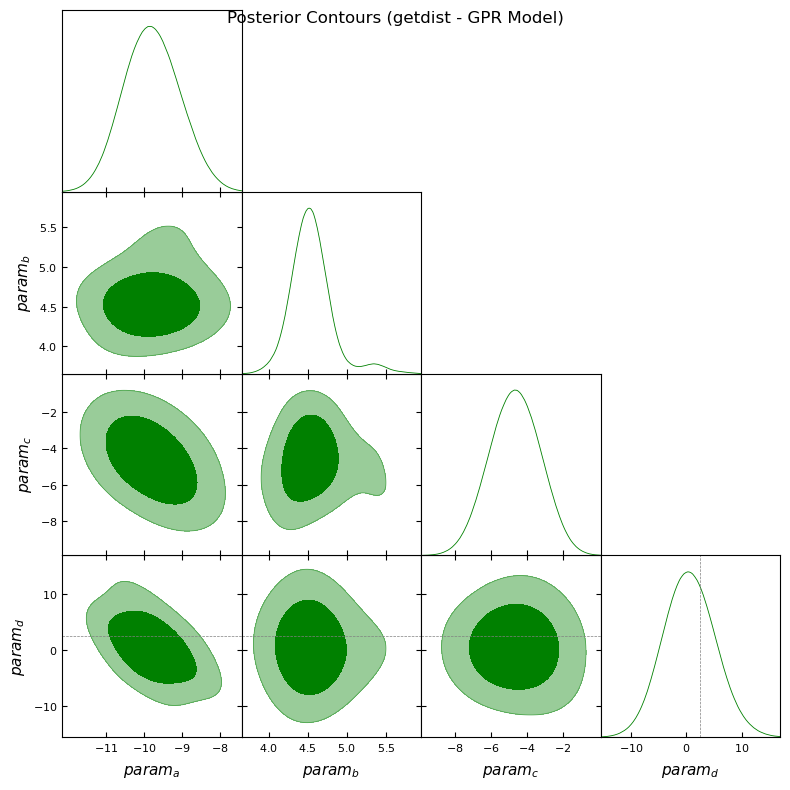

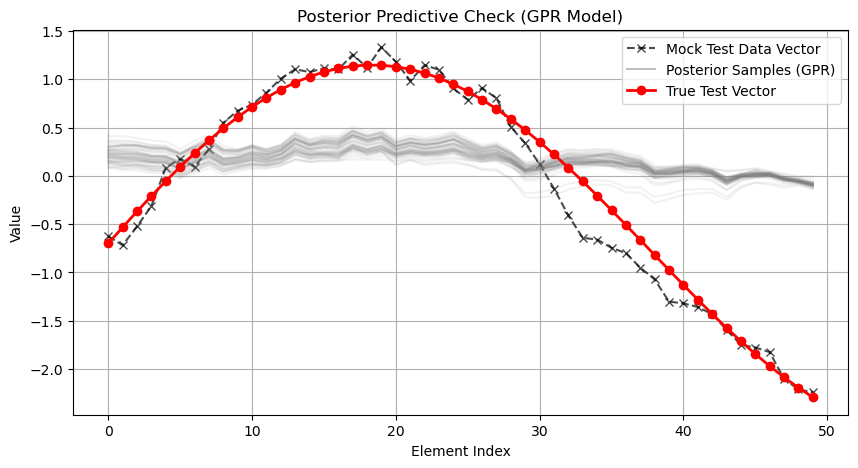


Script finished.


In [39]:

# 7. Create Triangle Plot with getdist for GPR-based inference
param_names_triangle = ['a', 'b', 'c', 'd']
true_values_triangle = true_values_test # Use test values for markers

# Convert posterior samples to numpy array
samples_numpy_gpr = np.vstack([posterior_samples_gpr[p].numpy() for p in param_names_triangle]).T

# Create an MCSamples object
names = param_names_triangle
labels = [f"param_{p}" for p in param_names_triangle]
mcs_gpr = MCSamples(samples=samples_numpy_gpr, names=names, labels=labels)

# Generate the triangle plot
g_gpr = plots.get_subplot_plotter()
g_gpr.triangle_plot(mcs_gpr,
                    filled=True,
                    markers={p: v for p, v in zip(param_names_triangle, true_values_triangle)},
                    legend_labels=[],
                    contour_colors=['green']) # Changed color for distinction

plt.suptitle("Posterior Contours (getdist - GPR Model)")
plt.show()

# 8. Optional: Posterior Predictive Check using the GPR model
plt.figure(figsize=(10, 5))
plt.plot(y_test_data.numpy(), label='Mock Test Data Vector', marker='x', linestyle='--', alpha=0.7, color='black')

# Plot a few posterior predictive samples (using GPR)
num_plot_samples = 50
indices = np.random.choice(num_mcmc_samples, num_plot_samples, replace=False)

# Pre-scale posterior samples for efficiency
posterior_params_numpy = np.vstack([posterior_samples_gpr[p].numpy() for p in param_names_triangle]).T
posterior_params_scaled = param_scaler.transform(posterior_params_numpy[indices, :])

# Get GPR predictions for these samples
y_gpr_preds_posterior, _ = gpr.predict(posterior_params_scaled, return_std=True)

for i in range(num_plot_samples):
    # y_pred_sample_numpy, _ = gpr.predict(posterior_params_scaled[i:i+1, :], return_std=True) # Predict one by one (slower)
    plt.plot(y_gpr_preds_posterior[i], color='gray', alpha=0.1) # Plot the GPR prediction

plt.plot([], [], color='gray', alpha=0.5, label='Posterior Samples (GPR)') # Dummy plot for legend
plt.plot(y_test_true.numpy(), label='True Test Vector', marker='o', linestyle='-', color='red', linewidth=2) # Compare with the true underlying vector for the test point
plt.xlabel('Element Index')
plt.ylabel('Value')
plt.title('Posterior Predictive Check (GPR Model)')
plt.legend()
plt.grid(True)
plt.show()

print("\nScript finished.")

